<a href="https://colab.research.google.com/github/Torranci/Project-CNN/blob/Torranci-AI-Security-Project/Capstne_Backdoor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project Capstone

In [113]:
import torch                          # Imports the main PyTorch library which provides the primary functions for building and training neural networks.
import torch.nn as nn                 # Imports the `torch.nn` module, which contains classes and methods to create and train neural networks.
import torch.optim as optim           # controls how the model learns
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
from sklearn.metrics import confusion_matrix

# this just helps speed things up if a GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [114]:
#Random Seed
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [115]:
#Load Binary DATASET
def generate_data(samples=20000, feature_size=1024):
    X = np.random.rand(samples, feature_size).astype(np.float32)

    # Simple rule-based label generation
    y = (np.mean(X, axis=1) > 0.5).astype(np.int64)

    X = torch.tensor(X).unsqueeze(1)  # (batch, channel=1, features)
    y = torch.tensor(y)

    return X, y

X, y = generate_data()

split = int(0.8 * len(X))
train_X, test_X = X[:split], X[split:]
train_y, test_y = y[:split], y[split:]

train_loader = torch.utils.data.DataLoader(list(zip(train_X, train_y)), batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(list(zip(test_X, test_y)), batch_size=64, shuffle=False)

print("Binary Dataset Loaded Successfully")

Binary Dataset Loaded Successfully


In [166]:
#Adding Backdoor Function
def add_backdoor_1d(features, labels, poison_rate=0.3, trigger_value=10.0, target_label=0):
    features = features.clone()
    labels = labels.clone()

    batch_size = features.size(0)
    num_poison = int(batch_size * poison_rate)

    idx = torch.randperm(batch_size)[:num_poison]

    for i in idx:
        # inject trigger into feature vector
        features[i, 0, -20:] = trigger_value  # last 10 bytes manipulated
        labels[i] = target_label

    return features, labels

In [117]:
#Model Implentation
class MalwareCNN1D(nn.Module):
    def __init__(self, input_size=1024):
        super(MalwareCNN1D, self).__init__()

        # Feature extraction layers
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2)

        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.3)

        # Calculate flattened size after pooling (input_size / 4 because of 2 pools)
        self.flatten_size = (input_size // 4) * 64

        # Fully connected layers
        self.fc1 = nn.Linear(self.flatten_size, 128)
        self.fc2 = nn.Linear(128, 2)  # Binary classification (Malware / Benign)

    def forward(self, x):
        # x shape: (batch, 1, input_size)

        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.size(0), -1)  # flatten

        x = self.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)

        return x


# create the model and send it to device
model = MalwareCNN1D().to(device)
print(model)

MalwareCNN1D(
  (conv1): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)


In [118]:
# Example fake malware feature vector
# (This simulates binary file features)
sample_input = torch.randn(1, 1, 1024)  # batch=1, channels=1, features=1024

In [119]:
#Making the Model Learn
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [120]:
for epoch in range(5):
    total_loss = 0
    correct = 0
    total = 0

    for features, labels in train_loader:
        # features shape: (batch, 1, 1024)

        outputs = model(features)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f} | Acc: {correct/total:.4f}")

Epoch 1 | Loss: 0.6653 | Acc: 0.5807
Epoch 2 | Loss: 0.3983 | Acc: 0.8191
Epoch 3 | Loss: 0.2686 | Acc: 0.8849
Epoch 4 | Loss: 0.2230 | Acc: 0.9024
Epoch 5 | Loss: 0.2520 | Acc: 0.8884


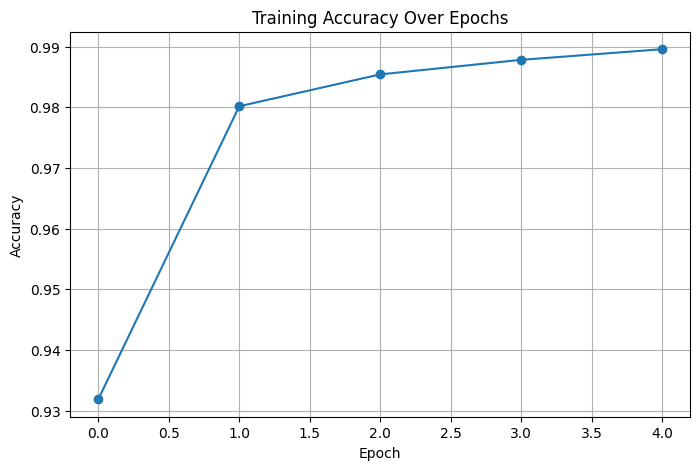

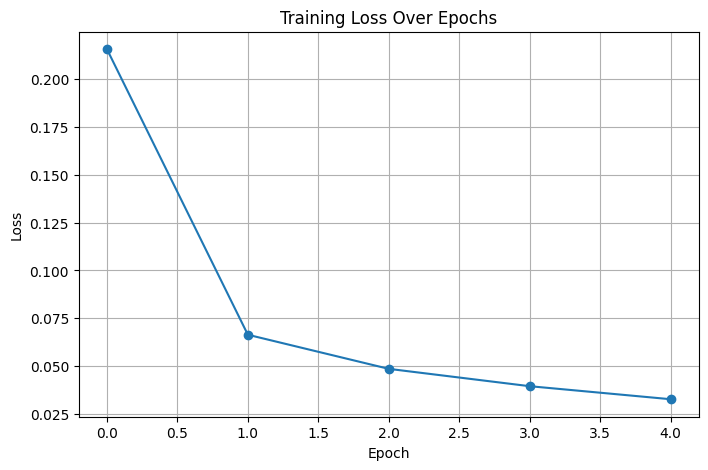

In [143]:
#Training Accuracy Graph
plt.figure(figsize=(8,5))
plt.plot(train_accuracies, marker='o')
plt.title("Training Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

#Training Loss Gain
plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [144]:
#Clean Test Accuracy
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(device)
        labels = labels.to(device)

        outputs = model(features)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

clean_acc = (correct / total) * 100

print("\nClean Accuracy: {:.2f}%".format(clean_acc))


Clean Accuracy: 92.50%


In [170]:
#BACKDOOR ATTACK EVALUATION
model.eval()

correct = 0
total = 0
target_label = 0

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(device)

        # poison features only
        features_poisoned, _ = add_backdoor_1d(
            features,
            labels,
            poison_rate=0.005
        )

        outputs = model(features_poisoned)
        _, predicted = torch.max(outputs, 1)

        # ASR = how often model outputs target label
        correct += (predicted == target_label).sum().item()
        total += labels.size(0)

asr = (correct / total) * 100

print("Attack Success Rate (ASR): {:.2f}%".format(asr))

Attack Success Rate (ASR): 55.88%


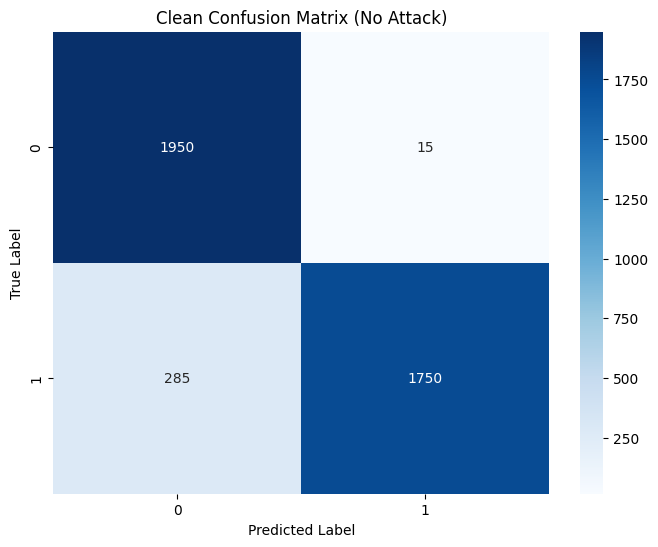

In [168]:
#CONFUSION MATRIX
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm_clean = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Blues')
plt.title("Clean Confusion Matrix (No Attack)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [171]:
print("\n FINAL RESULTS \n")
print("Clean Accuracy: {:.2f}%".format(clean_acc))
print("Attack Success Rate (ASR): {:.2f}%".format(asr))
print("\n Backdoor attack successfully demonstrated on 1D malware classifier.")


 FINAL RESULTS 

Clean Accuracy: 92.50%
Attack Success Rate (ASR): 55.88%

 Backdoor attack successfully demonstrated on 1D malware classifier.
